In [3]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import LabelEncoder

# 1. Load dataset with target names as strings
iris = load_iris(as_frame=True)
df = iris.frame

# By default, iris.target is already integers (0, 1, 2). 
# Let's map it back to string labels to demonstrate encoding:
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))

# 2. Fit and transform using LabelEncoder
label_encoder = LabelEncoder()
df['encoded_species'] = label_encoder.fit_transform(df['species'])

# Inspect mapping and output
print("Classes:", label_encoder.classes_)
print(df[['species', 'encoded_species']].drop_duplicates())

Classes: ['setosa' 'versicolor' 'virginica']
        species  encoded_species
0        setosa                0
50   versicolor                1
100   virginica                2


In [21]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
    RobustScaler,
    MaxAbsScaler
)

# 1. Prepare data
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------------------------------------
# 1. MinMaxScaler (scales to a fixed range, default [0, 1])
# Formula: (X - min) / (max - min)
# -------------------------------------------------------------
mms = MinMaxScaler()
X_train_mms = mms.fit_transform(X_train)
X_test_mms  = mms.transform(X_test)

# -------------------------------------------------------------
# 2. StandardScaler (scales to zero mean and unit variance)
# Formula: (X - mean) / std
# -------------------------------------------------------------
ss = StandardScaler()
X_train_ss = ss.fit_transform(X_train)
X_test_ss  = ss.transform(X_test)

# -------------------------------------------------------------
# 3. RobustScaler (scales using median and IQR; outlier-resistant)
# Formula: (X - median) / IQR
# -------------------------------------------------------------
rs = RobustScaler()
X_train_rs = rs.fit_transform(X_train)
X_test_rs  = rs.transform(X_test)

# -------------------------------------------------------------
# 4. MaxAbsScaler (scales each feature by its maximum absolute value, [-1, 1])
# Formula: X / max(|X|)  --> preserves sparsity
# -------------------------------------------------------------
mas = MaxAbsScaler()
X_train_mas = mas.fit_transform(X_train)
X_test_mas  = mas.transform(X_test)
print("MinMax scaler\n")
print(X_train_mms[:5])

print("\n robust scaler\n")
print(X_train_rs[:5])

print("\nstandard scaler scaler\n")
print(X_train_ss[:5])

print("\nMaxAbs scaler\n")
print(X_train_mms[:5])

MinMax scaler

[[0.02777778 0.375      0.05172414 0.04166667]
 [0.16666667 0.20833333 0.5862069  0.66666667]
 [0.69444444 0.33333333 0.63793103 0.54166667]
 [0.16666667 0.45833333 0.06896552 0.        ]
 [0.33333333 0.20833333 0.5        0.5       ]]

 robust scaler

[[-1.03846154 -0.19047619 -0.81428571 -0.73333333]
 [-0.65384615 -0.95238095  0.07142857  0.26666667]
 [ 0.80769231 -0.38095238  0.15714286  0.06666667]
 [-0.65384615  0.19047619 -0.78571429 -0.8       ]
 [-0.19230769 -0.95238095 -0.07142857  0.        ]]

standard scaler scaler

[[-1.72156775 -0.33210111 -1.34572231 -1.32327558]
 [-1.12449223 -1.22765467  0.41450518  0.6517626 ]
 [ 1.14439475 -0.5559895   0.58484978  0.25675496]
 [-1.12449223  0.11567567 -1.28894078 -1.45494479]
 [-0.40800161 -1.22765467  0.13059752  0.12508575]]

MaxAbs scaler

[[0.02777778 0.375      0.05172414 0.04166667]
 [0.16666667 0.20833333 0.5862069  0.66666667]
 [0.69444444 0.33333333 0.63793103 0.54166667]
 [0.16666667 0.45833333 0.06896552 0. 

In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
    RobustScaler,
    MaxAbsScaler,
    LabelEncoder
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# -------------------------------------------------------------
# 1. Load external dataset via read_csv
# -------------------------------------------------------------
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Select features and target
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
target = 'Survived'
df = df[features + [target]].copy()

# -------------------------------------------------------------
# 2. Check and fill missing (null) values
# -------------------------------------------------------------
print("Missing values before imputation:")
print(df.isnull().sum())
print("-" * 40)

# Fill null values
df['Age'] = df['Age'].fillna(df['Age'].median())

# Convert categorical column 'Sex' to numeric
df['Sex'] = LabelEncoder().fit_transform(df['Sex'])

print("Missing values after imputation:")
print(df.isnull().sum())
print("=" * 40)

# -------------------------------------------------------------
# 3. Train-Test Split with Stratification
# -------------------------------------------------------------
X = df[features].values
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------------------------------------
# 1. MinMaxScaler (scales to [0, 1])
# -------------------------------------------------------------
mms = MinMaxScaler()
X_train_mms = mms.fit_transform(X_train)
X_test_mms  = mms.transform(X_test)

# -------------------------------------------------------------
# 2. StandardScaler (mean = 0, std = 1)
# -------------------------------------------------------------
ss = StandardScaler()
X_train_ss = ss.fit_transform(X_train)
X_test_ss  = ss.transform(X_test)

# -------------------------------------------------------------
# 3. RobustScaler (median = 0, scaled by IQR)
# -------------------------------------------------------------
rs = RobustScaler()
X_train_rs = rs.fit_transform(X_train)
X_test_rs  = rs.transform(X_test)

# -------------------------------------------------------------
# 4. MaxAbsScaler (scales to [-1, 1] by absolute max)
# -------------------------------------------------------------
mas = MaxAbsScaler()
X_train_mas = mas.fit_transform(X_train)
X_test_mas  = mas.transform(X_test)

# -------------------------------------------------------------
# 4. Print transformed samples (First 5 rows)
# -------------------------------------------------------------
print("\nMinMax Scaler (First 5 Rows):\n", X_train_mms[:5])
print("\nRobust Scaler (First 5 Rows):\n", X_train_rs[:5])
print("\nStandard Scaler (First 5 Rows):\n", X_train_ss[:5])
print("\nMaxAbs Scaler (First 5 Rows):\n", X_train_mas[:5])

# -------------------------------------------------------------
# 5. Train K-Nearest Neighbors (KNN) and Print Accuracies
# -------------------------------------------------------------
print("\n" + "=" * 40)
print("ACCURACY COMPARISON (K-Nearest Neighbors)")
print("=" * 40)

# Raw / Unscaled
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
print(f"Unscaled Accuracy:       {accuracy_score(y_test, knn.predict(X_test)) * 100:.2f}%")

# MinMaxScaler
knn.fit(X_train_mms, y_train)
print(f"MinMaxScaler Accuracy:   {accuracy_score(y_test, knn.predict(X_test_mms)) * 100:.2f}%")

# StandardScaler
knn.fit(X_train_ss, y_train)
print(f"StandardScaler Accuracy: {accuracy_score(y_test, knn.predict(X_test_ss)) * 100:.2f}%")

# RobustScaler
knn.fit(X_train_rs, y_train)
print(f"RobustScaler Accuracy:   {accuracy_score(y_test, knn.predict(X_test_rs)) * 100:.2f}%")

# MaxAbsScaler
knn.fit(X_train_mas, y_train)
print(f"MaxAbsScaler Accuracy:   {accuracy_score(y_test, knn.predict(X_test_mas)) * 100:.2f}%")

Missing values before imputation:
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Survived      0
dtype: int64
----------------------------------------
Missing values after imputation:
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Survived    0
dtype: int64

MinMax Scaler (First 5 Rows):
 [[1.         1.         0.34656949 0.         0.         0.11027246]
 [0.5        1.         0.34656949 0.         0.         0.        ]
 [0.         1.         0.34656949 0.         0.         0.43288417]
 [1.         0.         0.22090978 0.         0.16666667 0.01824998]
 [0.5        0.         0.3842674  0.125      0.16666667 0.05123659]]

Robust Scaler (First 5 Rows):
 [[ 0.          0.          0.          0.          0.          1.81965184]
 [-1.          0.          0.          0.          0.         -0.6256092 ]
 [-2.          0.          0.          0.          0.          8.97347668]
 [ 0.         -1.    

In [35]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load dataset (Predict median house value in continuous $100k units)
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Feature Scaling (Crucial for Ridge/L2 regularized models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Fit Baseline Ordinary Least Squares (Linear Regression)
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

# 5. Fit Ridge Regression (alpha controls regularization strength λ)
ridge = Ridge(alpha=90, random_state=42)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)

# 6. Compare Performance
print("Linear Regression (OLS):")
print(f"  R² Score: {r2_score(y_test, lr_pred):.4f}")
print(f"  MSE:      {mean_squared_error(y_test, lr_pred):.4f}\n")

print("Ridge Regression (alpha=100.0):")
print(f"  R² Score: {r2_score(y_test, ridge_pred):.4f}")
print(f"  MSE:      {mean_squared_error(y_test, ridge_pred):.4f}\n")

# 7. Compare Learned Coefficients (Shrinkage effect)
print("Feature Coefficients Comparison:")
for feature, lr_coef, ridge_coef in zip(X.columns, lr.coef_, ridge.coef_):
    print(f"  {feature:<12} | OLS: {lr_coef:8.4f} | Ridge: {ridge_coef:8.4f}")

Linear Regression (OLS):
  R² Score: 0.5758
  MSE:      0.5559

Ridge Regression (alpha=100.0):
  R² Score: 0.5777
  MSE:      0.5534

Feature Coefficients Comparison:
  MedInc       | OLS:   0.8544 | Ridge:   0.8488
  HouseAge     | OLS:   0.1225 | Ridge:   0.1289
  AveRooms     | OLS:  -0.2944 | Ridge:  -0.2765
  AveBedrms    | OLS:   0.3393 | Ridge:   0.3172
  Population   | OLS:  -0.0023 | Ridge:  -0.0002
  AveOccup     | OLS:  -0.0408 | Ridge:  -0.0411
  Latitude     | OLS:  -0.8969 | Ridge:  -0.8340
  Longitude    | OLS:  -0.8698 | Ridge:  -0.8060


In [37]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# 2. Split into train and test sets (80% train, 20% test)
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Initialize the model
model = LogisticRegression(max_iter=200)

# 4. Configure 10-Fold cross-validation
cv = KFold(n_splits=10, shuffle=True, random_state=42)

# 5. Compute cross-validation scores on training data
results = cross_val_score(model, x_train, y_train, cv=cv)
fin_result = np.mean(results)

# 6. Display fold-by-fold results
print("--- 10-Fold Cross-Validation Scores (Training Set) ---")
for i, score in enumerate(results):
    print(f"Fold {i + 1} score: {score:.4f}")

print("-" * 50)
print(f"Mean CV Score: {fin_result:.4f} (+/- {np.std(results):.4f})")

# 7. Final fit and test set evaluation
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Unseen Test Set Accuracy: {test_accuracy:.4f}")

--- 10-Fold Cross-Validation Scores (Training Set) ---
Fold 1 score: 0.8333
Fold 2 score: 1.0000
Fold 3 score: 1.0000
Fold 4 score: 1.0000
Fold 5 score: 0.9167
Fold 6 score: 1.0000
Fold 7 score: 1.0000
Fold 8 score: 1.0000
Fold 9 score: 0.9167
Fold 10 score: 1.0000
--------------------------------------------------
Mean CV Score: 0.9667 (+/- 0.0553)
Unseen Test Set Accuracy: 0.9667


In [39]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Load Titanic dataset via URL
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Select features and target
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]
target = "Survived"
df = df[features + [target]].copy()

# 2. Preprocess: Imputation & Encoding
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Sex"] = LabelEncoder().fit_transform(df["Sex"])

# 3. Train-Test Split (80% Train, 20% Test)
X = df[features].values
y = df[target].values

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Feature Scaling (Fit on Train, Transform Test)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# 5. Initialize Model
model = LogisticRegression(max_iter=300, random_state=42)

# 6. Configure 10-Fold Cross-Validation
cv = KFold(n_splits=10, shuffle=True, random_state=42)

# 7. Compute 10-Fold Cross-Validation Accuracy Scores
cv_accuracies = cross_val_score(
    model, x_train_scaled, y_train, cv=cv, scoring="accuracy"
)
mean_cv_accuracy = np.mean(cv_accuracies)

# 8. Print Fold-by-Fold Accuracies
print("=" * 45)
print("10-FOLD CROSS-VALIDATION ACCURACY RESULTS")
print("=" * 45)
for i, acc in enumerate(cv_accuracies):
  print(f"Fold {i + 1:02d} Accuracy: {acc * 100:.2f}%")

print("-" * 45)
print(
    f"Mean CV Accuracy:     {mean_cv_accuracy * 100:.2f}% (+/-"
    f" {np.std(cv_accuracies) * 100:.2f}%)"
)

# 9. Train on Full Training Set and Evaluate on Unseen Holdout Test Set
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)

print("=" * 45)
print(f"Final Test Accuracy:  {test_accuracy * 100:.2f}%")
print("=" * 45)

10-FOLD CROSS-VALIDATION ACCURACY RESULTS
Fold 01 Accuracy: 80.56%
Fold 02 Accuracy: 70.83%
Fold 03 Accuracy: 73.24%
Fold 04 Accuracy: 74.65%
Fold 05 Accuracy: 77.46%
Fold 06 Accuracy: 78.87%
Fold 07 Accuracy: 78.87%
Fold 08 Accuracy: 78.87%
Fold 09 Accuracy: 87.32%
Fold 10 Accuracy: 87.32%
---------------------------------------------
Mean CV Accuracy:     78.80% (+/- 5.12%)
Final Test Accuracy:  80.45%


In [41]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load the Iris dataset (3 classes: Setosa, Versicolor, Virginica)
iris = load_iris()
X = iris.data
y = iris.target

# 2. Stratified train/test split (80% train, 20% holdout test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Model Initialization
model = LogisticRegression(max_iter=200, random_state=42)

# 5. 5-Fold Stratified Cross-Validation on Training Data
# Note: For multiclass targets, precision requires an average strategy ('macro' or 'weighted')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_acc = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
cv_prec = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='precision_macro')

print("=" * 55)
print("5-FOLD CROSS-VALIDATION RESULTS (IRIS TRAINING SET)")
print("=" * 55)
for i in range(len(cv_acc)):
    print(f"Fold {i+1} | Accuracy: {cv_acc[i]*100:6.2f}% | Precision (Macro): {cv_prec[i]*100:6.2f}%")

print("-" * 55)
print(f"Mean CV Accuracy:        {np.mean(cv_acc) * 100:.2f}% (+/- {np.std(cv_acc) * 100:.2f}%)")
print(f"Mean CV Precision:       {np.mean(cv_prec) * 100:.2f}% (+/- {np.std(cv_prec) * 100:.2f}%)")

# 6. Final Evaluation on Holdout Test Set
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
probabilities = model.predict_proba(X_test_scaled)

test_acc = accuracy_score(y_test, y_pred)
test_prec = precision_score(y_test, y_pred, average='macro')

print("=" * 55)
print(f"Final Test Accuracy:     {test_acc * 100:.2f}%")
print(f"Final Test Precision:    {test_prec * 100:.2f}%")
print("=" * 55)

# 7. Sample Prediction Scores (Probabilities for First 5 Test Samples)
print("\nSample Probabilities (Confidence Scores per Class):")
print(f"{'True':<8} | {'Predicted':<10} | {'Prob Class 0':<12} | {'Prob Class 1':<12} | {'Prob Class 2':<12}")
print("-" * 65)
for true_label, pred_label, probs in zip(y_test[:5], y_pred[:5], probabilities[:5]):
    print(f"{iris.target_names[true_label]:<8} | {iris.target_names[pred_label]:<10} | {probs[0]:<12.4f} | {probs[1]:<12.4f} | {probs[2]:<12.4f}")

5-FOLD CROSS-VALIDATION RESULTS (IRIS TRAINING SET)
Fold 1 | Accuracy:  95.83% | Precision (Macro):  96.30%
Fold 2 | Accuracy: 100.00% | Precision (Macro): 100.00%
Fold 3 | Accuracy:  95.83% | Precision (Macro):  96.30%
Fold 4 | Accuracy:  95.83% | Precision (Macro):  96.30%
Fold 5 | Accuracy:  91.67% | Precision (Macro):  93.33%
-------------------------------------------------------
Mean CV Accuracy:        95.83% (+/- 2.64%)
Mean CV Precision:       96.44% (+/- 2.12%)
Final Test Accuracy:     93.33%
Final Test Precision:    93.33%

Sample Probabilities (Confidence Scores per Class):
True     | Predicted  | Prob Class 0 | Prob Class 1 | Prob Class 2
-----------------------------------------------------------------
setosa   | setosa     | 0.9788       | 0.0212       | 0.0000      
virginica | virginica  | 0.0038       | 0.3692       | 0.6270      
versicolor | versicolor | 0.1488       | 0.8425       | 0.0087      
versicolor | versicolor | 0.0954       | 0.8946       | 0.0099      
s

In [52]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
X=np.array([[9.2,85,8],[8,80,7],[8.5,81,8],[6,45,4],[6.5,58,4],[8.2,72,7],[5.8,38,5],[8.9,91,9]])
y=np.array(['PASS','PASS','PASS','FAIL','FAIL','PASS','FAIL','PASS'])
model=KNeighborsClassifier(n_neighbors=3)
model.fit(X,y)
test=np.array([[6.1,40,5]])
p=model.predict(test)
print("result:",p[0])

result: FAIL


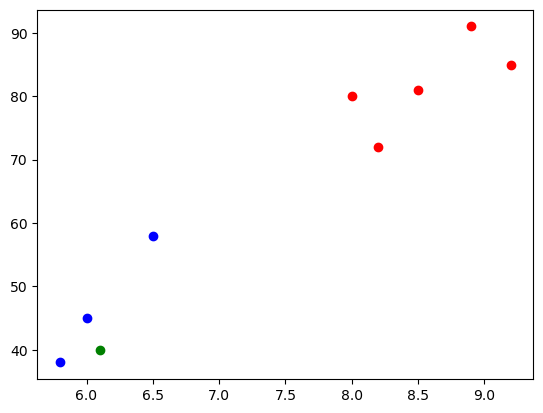

In [56]:
import matplotlib.pyplot as plt
x_pass=X[y=='PASS']
x_fail=X[y=='FAIL']
plt.scatter(x_pass[:, 0],x_pass[:, 1],color='red')
plt.scatter(x_fail[:, 0],x_fail[:, 1],color='blue')
plt.scatter(test[0][0],test[0][1],color='green')

In [58]:
# simple program to check student pass or fail using KNN
from sklearn.neighbors import KNeighborsClassifier

# This imports the KNN classification algorithm from Scikit-learn.
# Training data
X = [[1, 1], [2, 2], [3, 3], [7, 7], [8, 8], [9, 9]]
# each student is represented by two features internal marks and assignment marks.
y = ["Fail", "Fail", "Fail", "Pass", "Pass", "Pass"]

# Create KNN model
model = KNeighborsClassifier(n_neighbors=3)
# Look at the 3 nearest neighbors of the new data point.

# Train the model
model.fit(X, y)

# Test data
test = [[5, 5]]

# Prediction
prediction = model.predict(test)
print("Prediction:", prediction[0])
# Expected result: Prediction: Pass

Prediction: Fail


In [60]:
# implementaion in Python
import math

# Class A points
A = [(3, 1), (5, 2), (4, 3)]
# Class B points
B = [(7, 6), (6, 7), (8, 5)]

# Calculate centroids
centroid_A = (sum(x for x, y in A) / len(A), sum(y for x, y in A) / len(A))
centroid_B = (sum(x for x, y in B) / len(B), sum(y for x, y in B) / len(B))
print("Centroid A =", centroid_A)
print("Centroid B =", centroid_B)

# Test point
test = (6, 5)

# Calculate Euclidean distances
distance_A = math.sqrt(
    (test[0] - centroid_A[0]) ** 2 + (test[1] - centroid_A[1]) ** 2
)
distance_B = math.sqrt(
    (test[0] - centroid_B[0]) ** 2 + (test[1] - centroid_B[1]) ** 2
)
print("Distance to A =", distance_A)
print("Distance to B =", distance_B)

# Predict class
if distance_A < distance_B:
  print("Predicted Class = A")
else:
  print("Predicted Class = B")

Centroid A = (4.0, 2.0)
Centroid B = (7.0, 6.0)
Distance to A = 3.605551275463989
Distance to B = 1.4142135623730951
Predicted Class = B


In [64]:
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

for k in [1, 3, 5, 7, 9]:
  model = KNeighborsClassifier(n_neighbors=k)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  print("K =", k, "Accuracy =", accuracy)

K = 1 Accuracy = 1.0
K = 3 Accuracy = 1.0
K = 5 Accuracy = 1.0
K = 7 Accuracy = 1.0
K = 9 Accuracy = 1.0


Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date',
       'Time', 'Payment', 'Cost of goods sold', 'Gross margin percentage',
       'Gross income', 'Customer stratification rating'],
      dtype='object')
K = 1 Accuracy = 0.525
K = 3 Accuracy = 0.49
K = 5 Accuracy = 0.47
K = 7 Accuracy = 0.5
K = 9 Accuracy = 0.525


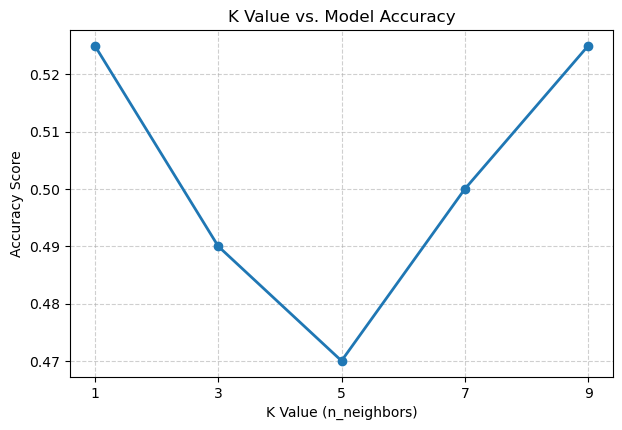

In [82]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(r"C:\Users\SIC\Downloads\supermarket-sales.csv")
print(df.columns)

X = df[["Unit price", "Quantity", "Tax 5%"]]
y = df["Customer type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Store values for plotting
k_values = [1, 3, 5, 7, 9]
accuracies = []

for k in k_values:
  model = KNeighborsClassifier(n_neighbors=k)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  accuracies.append(accuracy)
  print("K =", k, "Accuracy =", accuracy)

# Plot outside the loop
plt.figure(figsize=(7, 4.5))
plt.plot(
    k_values,
    accuracies,
    marker="o",
    color="#1f77b4",
    linewidth=2,
    markersize=6,
    linestyle="-",
)
plt.title("K Value vs. Model Accuracy")
plt.xlabel("K Value (n_neighbors)")
plt.ylabel("Accuracy Score")
plt.xticks(k_values)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

K = 1 | Standard KNN Acc: 0.5250 | Weighted KNN Acc: 0.5250
K = 3 | Standard KNN Acc: 0.4900 | Weighted KNN Acc: 0.5150
K = 5 | Standard KNN Acc: 0.4700 | Weighted KNN Acc: 0.4950
K = 7 | Standard KNN Acc: 0.5000 | Weighted KNN Acc: 0.5050
K = 9 | Standard KNN Acc: 0.5250 | Weighted KNN Acc: 0.5100
Nearest Centroid Accuracy: 0.5350


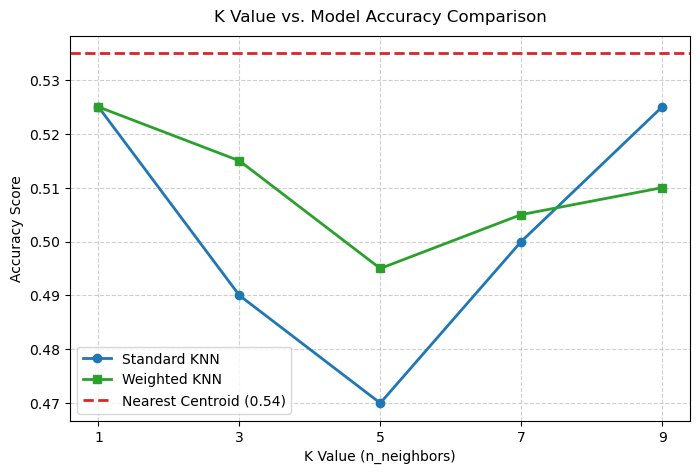

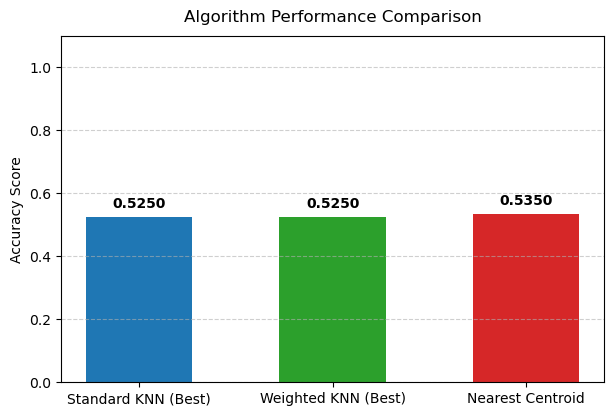

In [84]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.preprocessing import StandardScaler

# 1. Load Data
df = pd.read_csv(r"C:\Users\SIC\Downloads\supermarket-sales.csv")

X = df[["Unit price", "Quantity", "Tax 5%"]]
y = df["Customer type"]

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Evaluate Standard KNN and Weighted KNN across K values
k_values = [1, 3, 5, 7, 9]
knn_accuracies = []
wknn_accuracies = []

for k in k_values:
  # Standard KNN (uniform weights)
  knn = KNeighborsClassifier(n_neighbors=k, weights="uniform")
  knn.fit(X_train, y_train)
  acc_knn = accuracy_score(y_test, knn.predict(X_test))
  knn_accuracies.append(acc_knn)

  # Weighted KNN (inverse distance weights)
  wknn = KNeighborsClassifier(n_neighbors=k, weights="distance")
  wknn.fit(X_train, y_train)
  acc_wknn = accuracy_score(y_test, wknn.predict(X_test))
  wknn_accuracies.append(acc_wknn)

  print(
      f"K = {k} | Standard KNN Acc: {acc_knn:.4f} | Weighted KNN Acc:"
      f" {acc_wknn:.4f}"
  )

# 5. Evaluate Nearest Centroid (Centroid does not depend on K)
centroid = NearestCentroid()
centroid.fit(X_train, y_train)
acc_centroid = accuracy_score(y_test, centroid.predict(X_test))
print(f"Nearest Centroid Accuracy: {acc_centroid:.4f}")

# --- GRAPH 1: Line Plot (K vs Accuracy for all 3 algorithms) ---
plt.figure(figsize=(8, 5))
plt.plot(
    k_values,
    knn_accuracies,
    marker="o",
    linewidth=2,
    label="Standard KNN",
    color="#1f77b4",
)
plt.plot(
    k_values,
    wknn_accuracies,
    marker="s",
    linewidth=2,
    label="Weighted KNN",
    color="#2ca02c",
)

# Nearest Centroid is constant across K, shown as a reference dashed line
plt.axhline(
    y=acc_centroid,
    color="#d62728",
    linestyle="--",
    linewidth=2,
    label=f"Nearest Centroid ({acc_centroid:.2f})",
)

plt.title("K Value vs. Model Accuracy Comparison", fontsize=12, pad=10)
plt.xlabel("K Value (n_neighbors)", fontsize=10)
plt.ylabel("Accuracy Score", fontsize=10)
plt.xticks(k_values)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

# --- GRAPH 2: Bar Graph (Comparing Best Performance of the 3 Algorithms) ---
best_knn = max(knn_accuracies)
best_wknn = max(wknn_accuracies)

algorithms = ["Standard KNN (Best)", "Weighted KNN (Best)", "Nearest Centroid"]
final_scores = [best_knn, best_wknn, acc_centroid]
colors = ["#1f77b4", "#2ca02c", "#d62728"]

plt.figure(figsize=(7, 4.5))
bars = plt.bar(algorithms, final_scores, color=colors, width=0.55)

plt.title("Algorithm Performance Comparison", fontsize=12, pad=10)
plt.ylabel("Accuracy Score", fontsize=10)
plt.ylim(0, 1.1)
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Annotate accuracy values above bars
for bar in bars:
  yval = bar.get_height()
  plt.text(
      bar.get_x() + bar.get_width() / 2,
      yval + 0.02,
      f"{yval:.4f}",
      ha="center",
      va="bottom",
      fontweight="bold",
  )

plt.show()